In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_parquet('part_0010.parquet')

In [3]:
df

,h3_cell,date,future_accidents,label,accidents_today,speed_limit,road_type,first_road_class,first_road_number,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing,road_surface_conditions,weather_conditions,light_conditions,carriageway_hazards,urban_or_rural_area
0,8819590881fffff,2020-01-01,0,0,0,60,6,3,35,0,-1,0,-1,0,2,2,1,0,2
1,8819590881fffff,2020-01-02,0,0,0,60,6,3,35,0,-1,0,-1,0,2,2,1,0,2
2,8819590881fffff,2020-01-03,0,0,0,60,6,3,35,0,-1,0,-1,0,2,2,1,0,2
3,8819590881fffff,2020-01-04,0,0,0,60,6,3,35,0,-1,0,-1,0,2,2,1,0,2
4,8819590881fffff,2020-01-05,0,0,0,60,6,3,35,0,-1,0,-1,0,2,2,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9099995,88195aa101fffff,2024-12-20,0,0,0,70,3,1,4,0,-1,0,-1,0,1,1,1,0,2
9099996,88195aa101fffff,2024-12-21,0,0,0,70,3,1,4,0,-1,0,-1,0,1,1,1,0,2
9099997,88195aa101fffff,2024-12-22,0,0,0,70,3,1,4,0,-1,0,-1,0,1,1,1,0,2
9099998,88195aa101fffff,2024-12-23,0,0,0,70,3,1,4,0,-1,0,-1,0,1,1,1,0,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9100000 entries, 0 to 9099999
Data columns (total 19 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   h3_cell                  object
 1   date                     object
 2   future_accidents         int32 
 3   label                    int8  
 4   accidents_today          int32 
 5   speed_limit              int64 
 6   road_type                int64 
 7   first_road_class         int64 
 8   first_road_number        int64 
 9   junction_detail          int64 
 10  junction_control         int64 
 11  second_road_class        int64 
 12  second_road_number       int64 
 13  pedestrian_crossing      int64 
 14  road_surface_conditions  int64 
 15  weather_conditions       int64 
 16  light_conditions         int64 
 17  carriageway_hazards      int64 
 18  urban_or_rural_area      int64 
dtypes: int32(2), int64(14), int8(1), object(2)
memory usage: 1.2+ GB


In [5]:
# Sort for rolling operations
df = df.sort_values(['h3_cell', 'date'])

# Group by cell & compute rolling sums
df['acc_last_7'] = df.groupby('h3_cell')['accidents_today'] \
                      .rolling(7, min_periods=1).sum() \
                      .shift(1).reset_index(level=0, drop=True)

df['acc_last_30'] = df.groupby('h3_cell')['accidents_today'] \
                       .rolling(30, min_periods=1).sum() \
                       .shift(1).reset_index(level=0, drop=True)

print("DONE")

DONE


In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# create day_of_week / month / is_weekend
df['day_of_week'] = df['date'].dt.dayofweek.astype('Int8')   # 0=Mon .. 6=Sun
df['month'] = df['date'].dt.month.astype('Int8')
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype('Int8')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9100000 entries, 0 to 9099999
Data columns (total 24 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   h3_cell                  object        
 1   date                     datetime64[ns]
 2   future_accidents         int32         
 3   label                    int8          
 4   accidents_today          int32         
 5   speed_limit              int64         
 6   road_type                int64         
 7   first_road_class         int64         
 8   first_road_number        int64         
 9   junction_detail          int64         
 10  junction_control         int64         
 11  second_road_class        int64         
 12  second_road_number       int64         
 13  pedestrian_crossing      int64         
 14  road_surface_conditions  int64         
 15  weather_conditions       int64         
 16  light_conditions         int64         
 17  carriageway_hazards      in

In [8]:
import xgboost as xgb
bst=xgb.Booster()
bst.load_model('xgb_hotspot.model')

/var/folders/qt/8w5zy69d4c3_bvqdvxnrx3fw0000gn/T/ipykernel_40605/4018797921.py:3: UserWarning: [13:42:50] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  bst.load_model('xgb_hotspot.model')


In [9]:
feature_cols=[ 'accidents_today','acc_last_7', 'acc_last_30', 'day_of_week', 'month', 'is_weekend', 'speed_limit', 'road_type', 'junction_control', 'pedestrian_crossing', 'urban_or_rural_area', 'weather_conditions']

In [10]:
df['date']=pd.to_datetime(df['date'])

In [11]:
data_test=xgb.DMatrix(df[feature_cols],label=df['label'],feature_names=feature_cols)

In [12]:
y_pred=bst.predict(data_test,iteration_range=(0, bst.best_iteration + 1))

In [13]:

from sklearn.metrics import roc_auc_score, average_precision_score
auc=roc_auc_score(df['label'],y_pred)
ap=average_precision_score(df['label'],y_pred)
print(f"AUC:{auc:.4f},AveragePrecision(PR-AUC):{ap:.4f}")

AUC:0.7275,AveragePrecision(PR-AUC):0.0628


In [15]:
test_df = df.copy()
test_df['score'] = y_pred
cell_scores = (
    test_df
    .groupby('h3_cell')['score']
    .mean()
    .reset_index()
)

cell_future = (
    test_df
    .groupby('h3_cell')['future_accidents']
    .sum()
    .reset_index()
)
threshold = cell_future['future_accidents'].quantile(0.90)

cell_future['label'] = (
    cell_future['future_accidents'] >= threshold
).astype(int)
threshold = cell_future['future_accidents'].quantile(0.90)

cell_future['label'] = (
    cell_future['future_accidents'] >= threshold
).astype(int)
eval_df = cell_scores.merge(
    cell_future[['h3_cell', 'label']],
    on='h3_cell',
    how='inner'
)
print("Positive rate:", eval_df['label'].mean())


Positive rate: 0.1024


In [16]:
K = 500
K = min(K, len(eval_df))

precision_at_k = (
    eval_df
    .nlargest(K, 'score')['label']
    .mean()
)

print(f"Precision@{K}: {precision_at_k:.4f}")


Precision@500: 0.6100


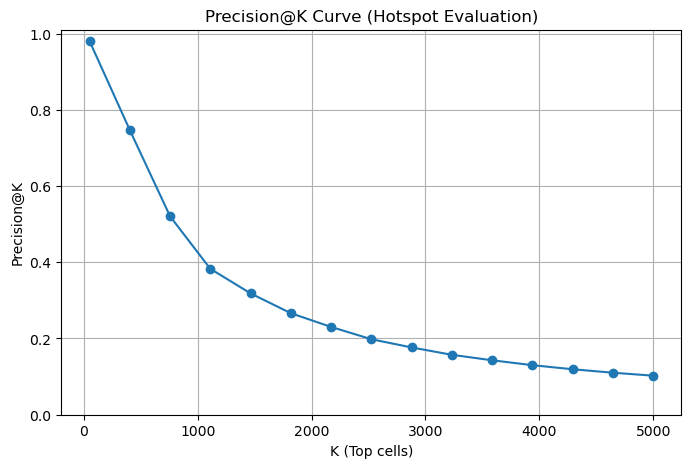

In [17]:
import numpy as np
import matplotlib.pyplot as plt

Ks = np.linspace(50, len(eval_df), 15, dtype=int)
precisions = []

for k in Ks:
    k = min(k, len(eval_df))
    p = eval_df.nlargest(k, 'score')['label'].mean()
    precisions.append(p)

plt.figure(figsize=(8,5))
plt.plot(Ks, precisions, marker='o')
plt.ylim(0, 1.01)
plt.xlabel("K (Top cells)")
plt.ylabel("Precision@K")
plt.title("Precision@K Curve (Hotspot Evaluation)")
plt.grid(True)
plt.show()


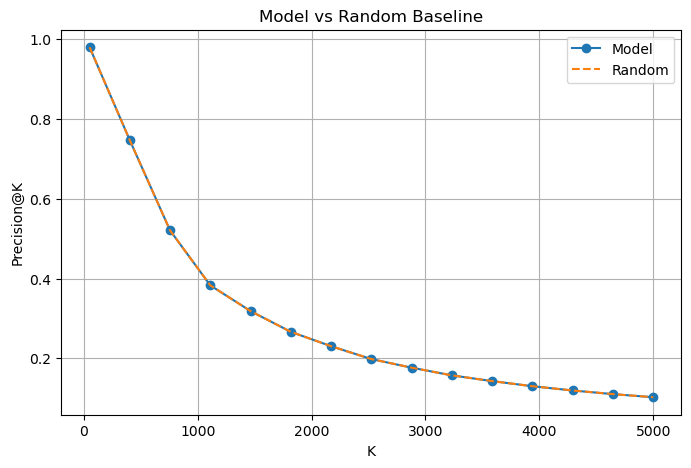

In [18]:
baseline = []

for k in Ks:
    k = min(k, len(eval_df))
    p = eval_df.sample(frac=1).nlargest(k, 'score')['label'].mean()
    baseline.append(p)

plt.figure(figsize=(8,5))
plt.plot(Ks, precisions, label="Model", marker='o')
plt.plot(Ks, baseline, label="Random", linestyle='--')
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Model vs Random Baseline")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
TOP_K =50  # choose 200–1000 depending on city scale

top_cells = (
    eval_df
    .sort_values('score', ascending=False)
    .head(TOP_K)
)
import folium
import h3

# Center map
m = folium.Map(
    location=[53.5,2.4],
    zoom_start=10,
    tiles="cartodbpositron"
)

for _, row in top_cells.iterrows():
    boundary = h3.cell_to_boundary(row['h3_cell'])
    
    folium.Polygon(
        locations=boundary,
        color="red",
        fill=True,
        fill_opacity=0.6,
        tooltip=f"""
        H3 Cell: {row['h3_cell']}
        Risk score: {row['score']:.3f}
        """
    ).add_to(m)

m


In [23]:
import branca.colormap as cm

colormap = cm.linear.YlOrRd_09.scale(
    top_cells['score'].min(),
    top_cells['score'].max()
)

for _, row in top_cells.iterrows():
    boundary = h3.cell_to_boundary(row['h3_cell'])
    
    folium.Polygon(
        locations=boundary,
        color=colormap(row['score']),
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Risk score: {row['score']:.3f}"
    ).add_to(m)

colormap.add_to(m)
m
